In [1]:
%load_ext autoreload
%autoreload 2

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import sys

# Add parent directory to path for imports
sys.path.insert(0, "/home/hgf_hmgu/hgf_gib4562/tdmpc2/tdmpc2/")

from analysis.load_run_data import load_run_data
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from rastermap import Rastermap
import numpy as np
from itertools import combinations
from sklearn.linear_model import RidgeCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
import pickle
from tqdm import tqdm
from sklearn.linear_model import LinearRegression, Lasso, MultiTaskLasso
from sklearn.metrics import r2_score

from analysis.utils import extract_variables
from rastermap import Rastermap

In [3]:
data = load_run_data(
    '/home/hgf_hmgu/hgf_gib4562/tdmpc2/sweeps_logs/initial_conditions',
    add_frames=True,
    n_frames=1)

Found 9 episode directories in /home/hgf_hmgu/hgf_gib4562/tdmpc2/sweeps_logs/initial_conditions
Loaded 9 episodes
Loaded 9 planning episodes


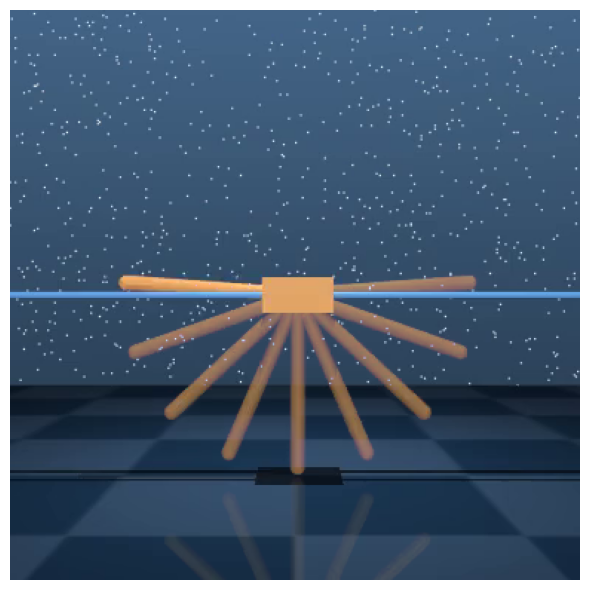

In [4]:
def overlap_frames(frames, pole_alpha=0.3, base_alpha=0.3):
    """
    Overlay multiple frames to show pole trajectory.
    
    Args:
        frames: List of frames to overlay
        pole_alpha: Visibility of the pole overlay (0=invisible, 1=fully visible)
        base_alpha: Visibility of the first frame (0=invisible, 1=fully visible)
    """
    # Filter out None values
    valid_frames = [f for f in frames if f is not None]

    if not valid_frames:
        raise ValueError("No valid frames to overlap")

    # Convert frames to float for processing
    frames_float = [f.astype(float) for f in valid_frames]

    # Use the first frame as the base with reduced visibility
    base_frame = frames_float[0].copy() * base_alpha

    # For subsequent frames, blend them in with reduced opacity
    for frame in frames_float[1:]:
        # Compute the maximum to capture the pole positions
        pole_overlay = np.maximum(base_frame, frame * pole_alpha)
        # Blend: keep more of the base, add pole with reduced alpha
        base_frame = base_frame * (1 - pole_alpha) + pole_overlay * pole_alpha

    # Convert back to uint8
    overlapped = np.clip(base_frame, 0, 255).astype('uint8')

    # Display the overlapped image
    fig, ax = plt.subplots(1, 1, figsize=(8, 6))
    ax.imshow(overlapped)
    ax.axis('off')
    plt.tight_layout()
    plt.show()

    return overlapped


overlapped_frame = overlap_frames(data['frames'],
                                  pole_alpha=0.8,
                                  base_alpha=1.0)

In [5]:
varsname_dict = {
    0: 'cart position',
    1: 'cos(pole angle)',
    2: 'sin(pole angle)',
    3: 'cart velocity',
    4: 'pole angular velocity',
}

varsname_dict_ext = {
    0: 'cart position',
    1: 'cos(pole angle)',
    2: 'sin(pole angle)',
    3: 'cart velocity',
    4: 'pole angular velocity',
    5: 'rewards',
    6: 'actions',
}

In [6]:
exp_vars = extract_variables(
    data,
    variables=['latent_states', 'observations', 'actions', 'rewards'],
    n_steps=500)

In [7]:
for var in exp_vars:
    print(f"{var}: {exp_vars[var][0].shape}")

latent_states: (500, 512)
observations: (500, 5)
actions: (500, 1)
rewards: (500, 1)


In [ ]:
latents, observations, actions, rewards = exp_vars['latent_states'], exp_vars[
    'observations'], exp_vars['actions'], exp_vars['rewards']

## Visualize observables 

In [94]:
def plot_episodes(exp_vars, n_episodes, samples_to_plot=None, sharey=False):

    n_cols = 3
    fig, axes = plt.subplots(n_episodes,
                             n_cols,
                             figsize=(6 * n_cols, 5 * n_episodes),
                             dpi=300)

    # Ensure axes is 2D array
    if n_episodes == 1 and n_cols == 1:
        axes = np.array([[axes[0], axes[1], axes[2]]])
    elif n_episodes == 1:
        axes = axes.reshape(1, -1)
    elif n_cols == 1:
        axes = axes.reshape(-1, 3)
    else:
        axes = axes.reshape(n_episodes, -1)

    for episode_idx in range(n_episodes):
        col_start = 0

        obs = exp_vars['observations'][episode_idx]
        actions = exp_vars['actions'][episode_idx]
        rewards = exp_vars['rewards'][episode_idx]
        timesteps = np.arange(len(actions))

        if samples_to_plot is not None:
            obs = obs[:samples_to_plot]
            actions = actions[:samples_to_plot]
            rewards = rewards[:samples_to_plot]
            timesteps = timesteps[:samples_to_plot]

        # Plot observations
        ax = axes[episode_idx, col_start]
        for dim in range(obs.shape[1]):
            ax.plot(timesteps,
                    obs[:, dim],
                    linewidth=2,
                    alpha=0.8,
                    label=f'{varsname_dict[dim]}')
        ax.legend(fontsize=10, loc='best')
        ax.set_xlabel('Timestep', fontsize=12)
        ax.set_ylabel('Observation Value', fontsize=12)
        ax.set_title(f'Episode {episode_idx} - Observations',
                     fontsize=14,
                     fontweight='bold')
        ax.grid(True, alpha=0.3)

        # Plot actions
        ax = axes[episode_idx, col_start + 1]
        ax.plot(timesteps, actions, linewidth=2, color='coral')
        ax.set_xlabel('Timestep', fontsize=12)
        ax.set_ylabel('Action Value', fontsize=12)
        ax.set_title(f'Episode {episode_idx} - Actions',
                     fontsize=14,
                     fontweight='bold')
        ax.grid(True, alpha=0.3)

        # Plot rewards
        ax = axes[episode_idx, col_start + 2]
        ax.plot(timesteps, rewards, linewidth=2, color='green', alpha=0.8)
        ax.set_xlabel('Timestep', fontsize=12)
        ax.set_ylabel('Reward', fontsize=12)
        ax.set_title(
            f'Episode {episode_idx} - Rewards (Total: {np.sum(rewards):.2f})',
            fontsize=14,
            fontweight='bold')
        ax.grid(True, alpha=0.3)

    # Share y-axis per column if requested
    if sharey:
        for col_idx in range(n_cols):
            ylims = []
            for episode_idx in range(n_episodes):
                ylims.append(axes[episode_idx, col_idx].get_ylim())

            # Get the overall min and max for this column
            ymin = min([lim[0] for lim in ylims])
            ymax = max([lim[1] for lim in ylims])

            # Apply to all axes in this column
            for episode_idx in range(n_episodes):
                axes[episode_idx, col_idx].set_ylim(ymin, ymax)

    plt.tight_layout()
    sns.despine()
    plt.show()


# Plot episodes
n_episodes_to_plot = 9
plot_episodes(
    exp_vars,
    n_episodes_to_plot,
    samples_to_plot=300,
    sharey=True,
)

## Visualize latent states and auxiliary variables

In [42]:
def fit_rastermap(data,
                  n_PCs=200,
                  n_clusters=100,
                  locality=0.75,
                  time_lag_window=10):
    """Fit Rastermap model to data and return embedding results."""
    model = Rastermap(n_PCs=n_PCs,
                      n_clusters=n_clusters,
                      locality=locality,
                      time_lag_window=time_lag_window).fit(data)

    y = model.embedding  # neurons x 1
    isort = model.isort
    # visualize binning over neurons
    X_embedding = model.X_embedding

    return model, y, isort, X_embedding

In [ ]:
# # Fit Rastermap to latent states for each episode
samples_to_fit = 300

# rastermap_results = {}
# for episode_idx in range(len(latents)):
#     latent_data = latents[
#         episode_idx][:
#                      samples_to_fit].T  # in rastermap we need latent dims x timepoints
#     model, y, isort, X_embedding = fit_rastermap(latent_data,
#                                                  n_PCs=200,
#                                                  n_clusters=100,
#                                                  locality=0.75,
#                                                  time_lag_window=10)
#     rastermap_results[episode_idx] = {
#         'model': model,
#         'embedding': y,
#         'isort': isort,
#         'X_embedding': X_embedding
#     }

# import pickle
# with open('rastermap_results.pkl', 'wb') as f:
#     pickle.dump(rastermap_results, f)

# rastermap_results_shuffled = {}
# n_shuffles = 2
# for episode_idx in range(n_shuffles):
#     # shuffle control
#     latent_data = latents[
#         episode_idx][:
#                      samples_to_fit].T  # in rastermap we need latent dims x timepoints

#     # shuffle time dimensions, keeping latent dims fixed
#     latent_data = latent_data[:, np.random.permutation(latent_data.shape[1])]
#     model, y, isort, X_embedding = fit_rastermap(latent_data,
#                                                  n_PCs=200,
#                                                  n_clusters=100,
#                                                  locality=0.75,
#                                                  time_lag_window=10)
#     rastermap_results[f'shuffled_{episode_idx}'] = {
#         'model': model,
#         'embedding': y,
#         'isort': isort,
#         'X_embedding': X_embedding,
#         'latent_data': latent_data
#     }

In [71]:
rastermap_results_v0 = rastermap_results.copy()
del rastermap_results_v0['shuffled_0']
del rastermap_results_v0['shuffled_1']
del rastermap_results_v0['shuffled_2']

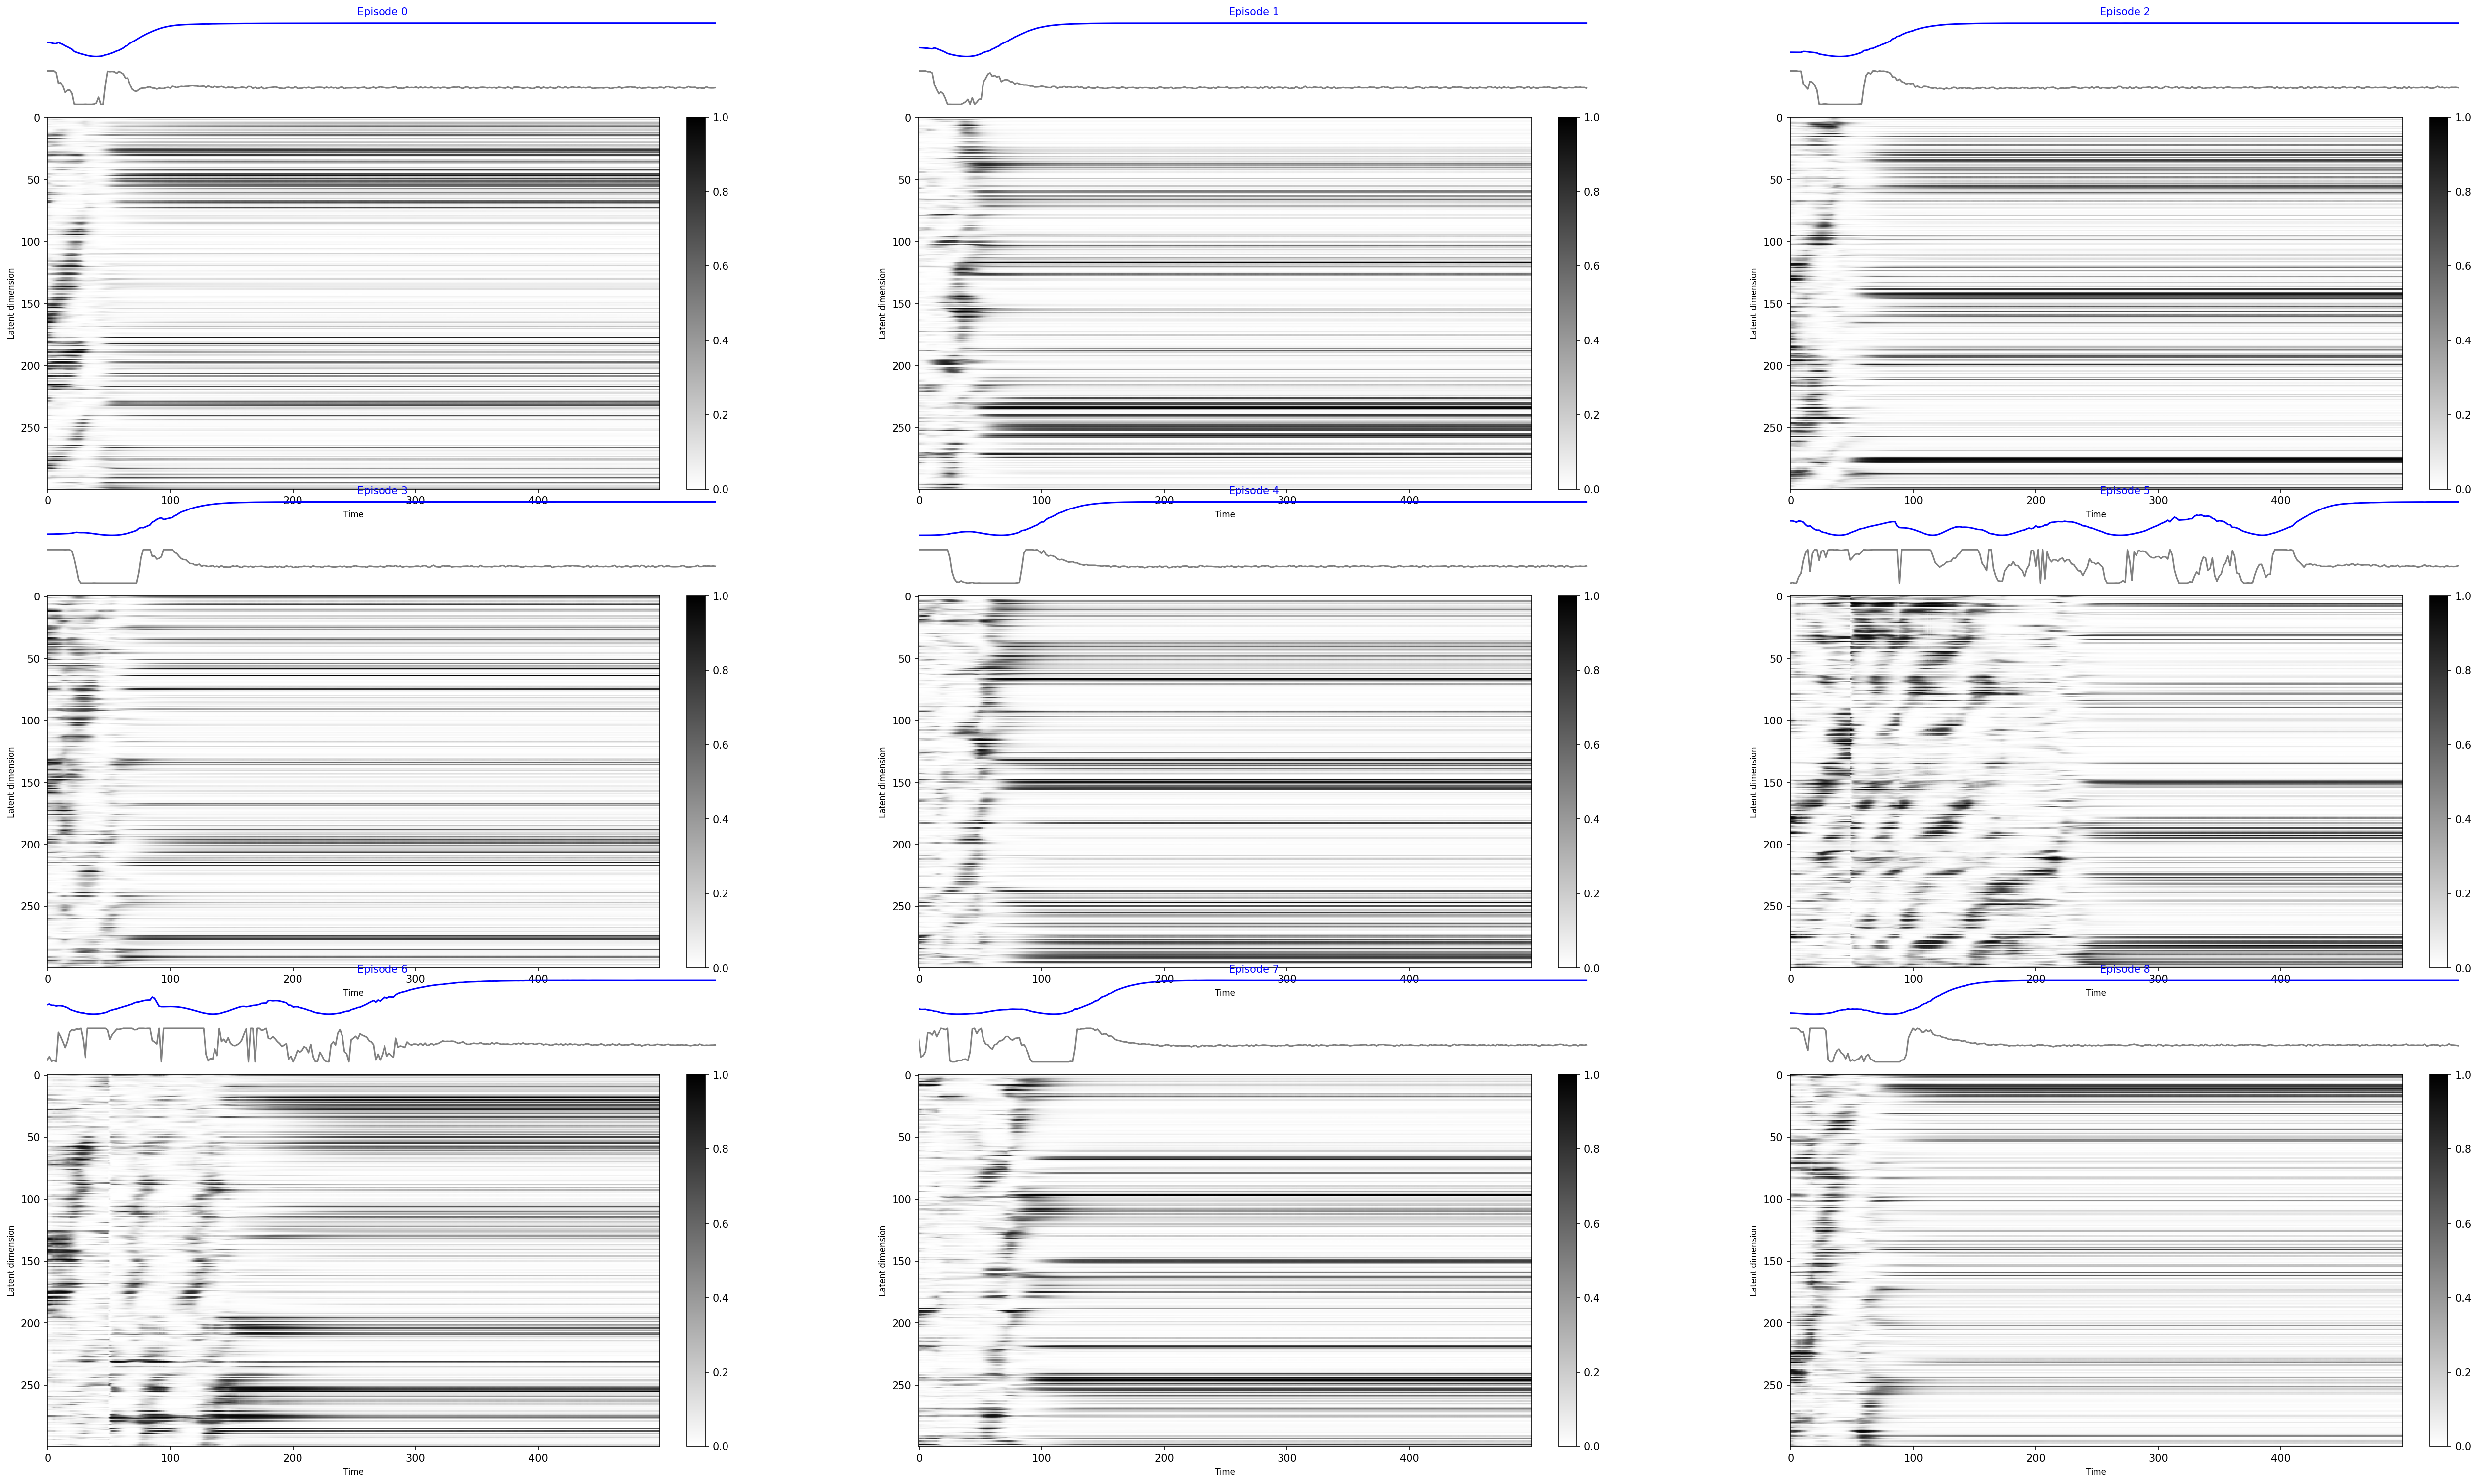

In [96]:
def plot_rastermap_with_rewards_actions(rastermap_results,
                                        rewards,
                                        actions,
                                        latents,
                                        plot_type='embedding',
                                        n_cols=3,
                                        points_to_plot=None):

    # Collect all episode indices (excluding shuffled)
    episode_indices = [
        idx for idx in rastermap_results.keys() if 'shuffled' not in str(idx)
    ]

    n_episodes = len(episode_indices)
    n_rows = (n_episodes + n_cols - 1) // n_cols  # Ceiling division

    # Create figure with subplots
    fig = plt.figure(figsize=(14 * n_cols, 10 * n_rows), dpi=150)

    for plot_idx, episode_idx in enumerate(episode_indices):
        # Get results for this episode
        X_embedding = rastermap_results[episode_idx]['X_embedding']
        isort = rastermap_results[episode_idx]['isort']
        latents_rm_sorted = latents[episode_idx].T[isort]

        if points_to_plot is not None:
            X_embedding = X_embedding[:, :points_to_plot]
            latents_rm_sorted = latents_rm_sorted[:points_to_plot]
            rewards_to_plot = rewards[episode_idx][:points_to_plot]
            actions_to_plot = actions[episode_idx][:points_to_plot]

        # Calculate position in grid
        row = plot_idx // n_cols
        col = plot_idx % n_cols

        # Create GridSpec for this subplot (10 rows for rewards, actions, and main plot)
        grid = plt.GridSpec(12 * n_rows,
                            n_cols,
                            figure=fig,
                            hspace=0.3,
                            wspace=0.3)

        # Rewards subplot
        ax_rewards = plt.subplot(grid[row * 10:(row * 10) + 1, col])
        ax_rewards.plot(rewards_to_plot, color='blue')
        ax_rewards.set_xlim([0, X_embedding.shape[1]])
        ax_rewards.set_ylabel("rewards", fontsize=8)
        ax_rewards.set_title(f"Episode {episode_idx}",
                             color='blue',
                             fontsize=10)
        ax_rewards.axis("off")

        # Actions subplot
        ax_actions = plt.subplot(grid[(row * 10) + 1:(row * 10) + 2, col])
        ax_actions.plot(actions_to_plot, color='gray')
        ax_actions.set_xlim([0, X_embedding.shape[1]])
        ax_actions.set_ylabel("actions", fontsize=8)
        ax_actions.axis("off")

        # Main plot (embedding/latents/superneuron)
        ax_main = plt.subplot(grid[(row * 10) + 2:(row * 10) + 10, col])

        if plot_type == 'embedding':
            im = ax_main.imshow(X_embedding,
                                vmin=0,
                                vmax=1.5,
                                cmap="gray_r",
                                aspect="auto",
                                interpolation='none')
            ax_main.set_xlabel("Time", fontsize=8)
            ax_main.set_ylabel("Embedding bins", fontsize=8)

        elif plot_type == 'latents':
            im = ax_main.imshow(latents_rm_sorted,
                                vmin=0,
                                vmax=1,
                                cmap="gray_r",
                                aspect="auto",
                                interpolation='none')
            ax_main.set_xlabel("Time", fontsize=8)
            ax_main.set_ylabel("Latent dimension", fontsize=8)

        elif plot_type == 'superneuron':
            nbin = 8  # number of neurons to bin over
            ndiv = (latents_rm_sorted.shape[0] // nbin) * nbin
            # group sorted matrix into rows of length nbin
            sn = latents_rm_sorted[:ndiv].reshape(ndiv // nbin, nbin, -1)
            # take mean over neurons in a bin
            sn = sn.mean(axis=1)

            im = ax_main.imshow(sn,
                                vmin=0,
                                vmax=1,
                                cmap="gray_r",
                                aspect="auto",
                                interpolation='none')
            ax_main.set_xlabel("Time", fontsize=8)
            ax_main.set_ylabel(f"Superneuron bins (n={nbin})", fontsize=8)

        # Add colorbar for each subplot
        plt.colorbar(im, ax=ax_main, fraction=0.046, pad=0.04)

    # Hide any unused subplots
    for idx in range(n_episodes, n_rows * n_cols):
        row = idx // n_cols
        col = idx % n_cols
        ax_dummy = plt.subplot(grid[row * 10:(row * 10) + 10, col])
        ax_dummy.axis('off')

    #plt.tight_layout()
    plt.show()
    return fig


# Example usage:
fig = plot_rastermap_with_rewards_actions(
    rastermap_results=rastermap_results,
    rewards=rewards,
    actions=actions,
    latents=latents,
    plot_type='latents',  # or 'latents' or 'superneuron'
    n_cols=3,
    points_to_plot=300)


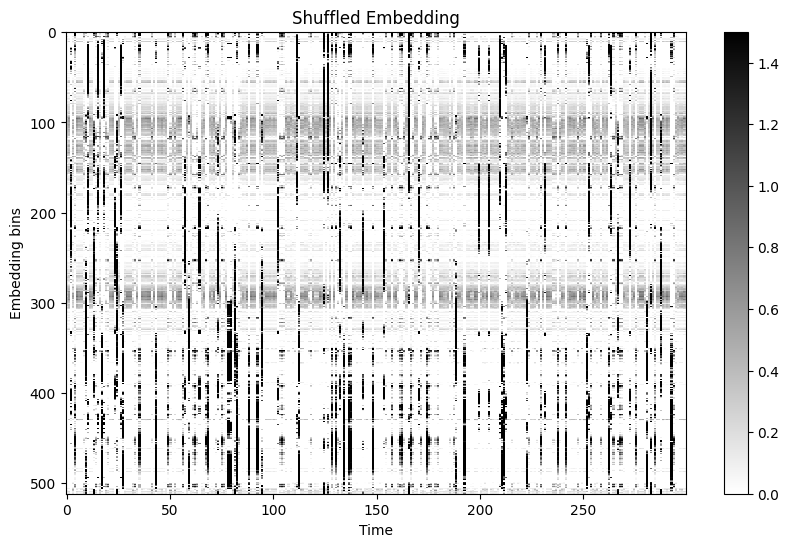

In [65]:
embedding_shuffled = rastermap_results['shuffled_1']['X_embedding']

# plot embedding
fig, ax = plt.subplots(figsize=(10, 6))
im = ax.imshow(embedding_shuffled,
               vmin=0,
               vmax=1.5,
               cmap="gray_r",
               aspect="auto",
               interpolation='none')
ax.set_xlabel("Time")
ax.set_ylabel("Embedding bins")
plt.colorbar(im, ax=ax)
plt.title("Shuffled Embedding")
plt.show()

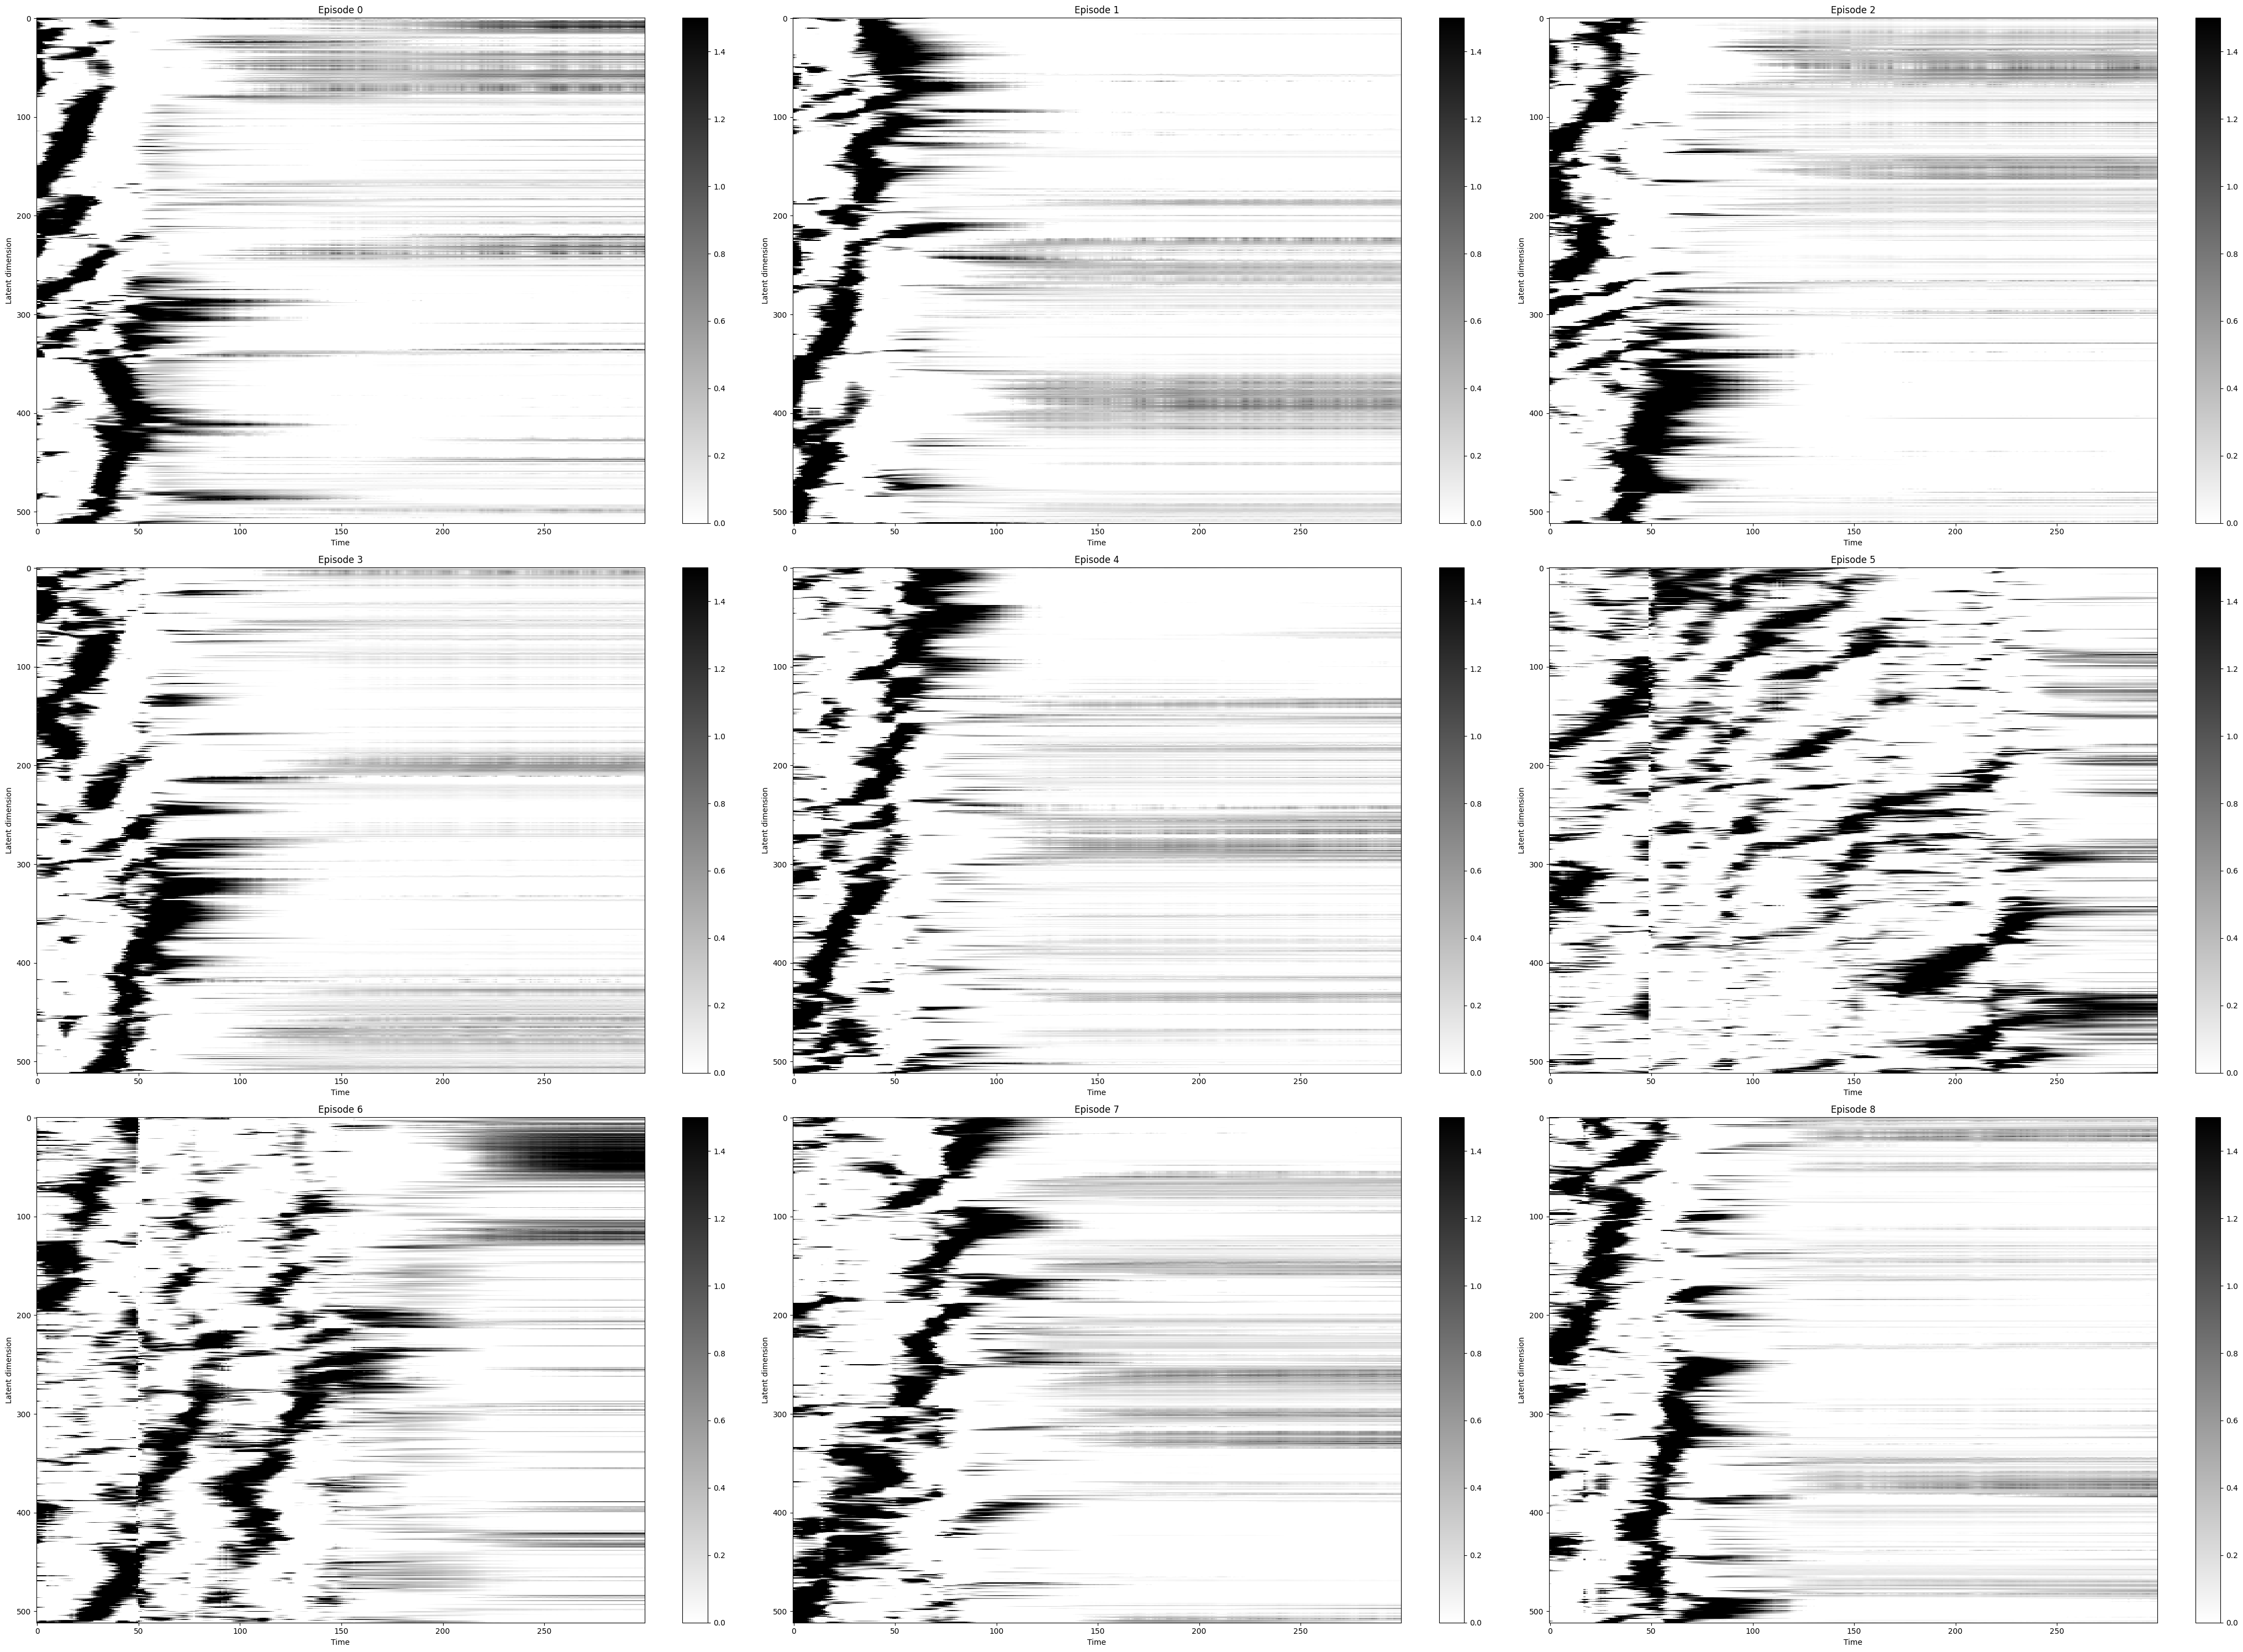

In [67]:
# Plot for each episode
plot_type = 'embedding'  # 'latents', 'embedding', or 'superneuron'

# Collect all episode indices (excluding shuffled)
episode_indices = [
    idx for idx in rastermap_results.keys() if 'shuffled' not in str(idx)
]

# Calculate number of rows needed for 3 plots per row
n_episodes = len(episode_indices)
n_cols = 3
n_rows = (n_episodes + n_cols - 1) // n_cols  # Ceiling division

# Create subplots
fig, axes = plt.subplots(n_rows, n_cols, figsize=(42, 10 * n_rows))
if n_rows == 1:
    axes = axes.reshape(1, -1)

# Flatten axes for easier iteration
axes_flat = axes.flatten()

for idx, episode_idx in enumerate(episode_indices):
    ax = axes_flat[idx]

    # Get the data for this episode
    latent_data = latents[episode_idx] if 'shuffled' not in str(
        episode_idx) else rastermap_results[episode_idx]['latent_data']

    # Plot rastermap
    if plot_type == 'latents':
        im = ax.imshow(latent_data,
                       vmin=0,
                       vmax=1.5,
                       cmap="gray_r",
                       aspect="auto",
                       interpolation='none')
    elif plot_type == 'embedding':
        embedding = rastermap_results[episode_idx]['X_embedding']
        im = ax.imshow(embedding,
                       vmin=0,
                       vmax=1.5,
                       cmap="gray_r",
                       aspect="auto",
                       interpolation='none')
    elif plot_type == 'superneuron':
        nbin = 8
        latents_rm_sorted = rastermap_results[episode_idx]['latents_rm_sorted']
        ndiv = (latents_rm_sorted.shape[0] // nbin) * nbin
        sn = latents_rm_sorted[:ndiv].reshape(ndiv // nbin, nbin, -1)
        sn = sn.mean(axis=1)
        im = ax.imshow(sn,
                       vmin=0,
                       vmax=1,
                       cmap="gray_r",
                       aspect="auto",
                       interpolation='none')

    ax.set_xlabel("Time")
    ax.set_ylabel("Latent dimension" if plot_type !=
                  'superneuron' else f"Superneuron bins")
    ax.set_title(f"Episode {episode_idx}")
    plt.colorbar(im, ax=ax)

# Hide any unused subplots
for idx in range(n_episodes, len(axes_flat)):
    axes_flat[idx].axis('off')

plt.tight_layout()
plt.show()


# Linear decoding


In [9]:
def make_lagged_pairs_for_episode(x_ep, y_ep, lag):
    """Build (X, Y) pairs within one episode for given lag."""
    T = len(x_ep)
    if lag >= 0:
        t_src = np.arange(0, T - lag)
        t_tgt = t_src + lag

    elif lag < 0:
        # Predict the past: (z_t, y_{t+lag}) = (z_t, y_{t-|lag|})
        shift = abs(lag)
        t_src = np.arange(shift, T)
        t_tgt = np.arange(0, T - shift)

    return x_ep[t_src], y_ep[t_tgt]


def bootstrap_ci(vals, alpha=0.05, n_boot=1000):
    rng = np.random.RandomState(0)
    boot_means = np.zeros(n_boot)
    for b in range(n_boot):
        resampled = rng.choice(vals, size=len(vals), replace=True)
        boot_means[b] = np.mean(resampled)

    lower = np.percentile(boot_means, alpha)
    upper = np.percentile(boot_means, 100 - alpha)
    return (lower, upper)

In [ ]:
def evaluate_lags_leave_k_out(x_eps,
                              y_eps,
                              lags,
                              k_holdout=1,
                              model='linear_regression',
                              max_combinations=None,
                              add_bootstrap_ci=False,
                              alpha=0.05,
                              n_bootstrap=1000,
                              shuffle_X=False,
                              shuffle_y=False):
    """
    Args:
        x_eps: list of [N_eps_i, L] arrays
        y_eps: list of [N_eps_i, D] arrays   
    """
    n_eps = len(x_eps)
    assert n_eps > k_holdout, "k_holdout must be smaller than number of episodes"

    # Enumerate folds (all combinations or sampled subset)
    all_combos = list(combinations(range(n_eps), k_holdout))
    if max_combinations is not None and len(all_combos) > max_combinations:
        np.random.seed(0)
        all_combos = list(
            np.random.choice(len(all_combos), max_combinations, replace=False))

    if shuffle_X:
        x_eps = [np.random.permutation(x_ep) for x_ep in x_eps]
    if shuffle_y:
        y_eps = [np.random.permutation(y_ep) for y_ep in y_eps]

    r2_by_lag = {lag: [] for lag in lags}
    model_by_lag = {lag: [] for lag in lags}

    for test_idxs in tqdm(all_combos):
        test_idxs = np.atleast_1d(test_idxs)
        train_idxs = [i for i in range(n_eps) if i not in test_idxs]

        for lag in lags:
            # Collect training pairs
            X_train_list, Y_train_list = [], []
            for i in train_idxs:
                X_i, Y_i = make_lagged_pairs_for_episode(
                    x_eps[i], y_eps[i], lag)
                X_train_list.append(X_i)
                Y_train_list.append(Y_i)

            X_train = np.concatenate(X_train_list, axis=0)
            Y_train = np.concatenate(Y_train_list, axis=0)

            if model == 'linear_regression':
                model_to_fit = LinearRegression()
            elif model == 'lasso':
                model_to_fit = MultiTaskLasso(alpha=0.001, max_iter=2000)
            # elif model == 'lasso_cv':
            #     from sklearn.linear_model import MultiTaskLasso
            #     model_to_fit = MultiTaskLassoCV(cv=5,
            #                                     n_alphas=20,
            #                                     random_state=123)
            elif model == 'multi_task_lasso':
                model_to_fit = MultiTaskLasso(alpha=0.01)
            else:
                raise ValueError(f"Model {model} not supported")

            # Fit model on training set
            model_to_fit = model_to_fit.fit(X_train, Y_train)

            # Evaluate on each held-out episode
            fold_r2s = []
            for j in test_idxs:
                X_te, Y_te = make_lagged_pairs_for_episode(
                    x_eps[j], y_eps[j], lag)
                Y_pred = model_to_fit.predict(X_te)
                r2 = r2_score(Y_te, Y_pred, multioutput='variance_weighted')
                fold_r2s.append(r2)

            r2_by_lag[lag].append(
                np.mean(fold_r2s))  # mean R² over held-out eps in this fold

            model_by_lag[lag].append(model_to_fit)

    # Aggregate mean and std over folds
    r2_mean = {lag: np.mean(vals) for lag, vals in r2_by_lag.items()}
    r2_std = {lag: np.std(vals, ddof=1) for lag, vals in r2_by_lag.items()}

    results = {
        'r2_mean': r2_mean,
        'r2_std': r2_std,
        'r2_by_lag': r2_by_lag,
        'model_by_lag': model_by_lag,
    }

    if add_bootstrap_ci:
        r2_ci = {
            lag: bootstrap_ci(vals, alpha=alpha, n_boot=n_bootstrap)
            for lag, vals in r2_by_lag.items()
        }
        results['r2_ci'] = r2_ci

    return results

In [116]:
results_decoding = {}

combinations_vars = [
    ('latent_states', 'observations'),
    ('latent_states', 'rewards'),
    ('latent_states', 'actions'),
    ('latent_states', 'latent_states'),
    ('observations', 'observations'),
    ('rewards', 'rewards'),
    ('actions', 'actions'),
]

#models_to_fit = ['linear_regression', 'lasso']
models_to_fit = ['linear_regression']

for model in models_to_fit:
    for x_var, y_var in combinations_vars:
        print(f"Decoding {x_var} -> {y_var} with {model}")
        if 'latent_states-latent_states' in results_decoding and model == 'lasso':
            continue
        results_decoding[f'{x_var}-{y_var}'] = evaluate_lags_leave_k_out(
            exp_vars[x_var],
            exp_vars[y_var],
            model=model,
            lags=np.arange(-50, 51),
            k_holdout=1,
            add_bootstrap_ci=True,
            shuffle_X=False,
            shuffle_y=False)

    #Save results_decoding to pickle file
    with open(f'results_decoding_{model}.pkl', 'wb') as f:
        pickle.dump(results_decoding, f)

Decoding latent_states -> observations with linear_regression


  0%|          | 0/9 [00:00<?, ?it/s]

100%|██████████| 9/9 [01:03<00:00,  7.04s/it]


Decoding latent_states -> rewards with linear_regression


100%|██████████| 9/9 [01:02<00:00,  6.94s/it]


Decoding latent_states -> actions with linear_regression


100%|██████████| 9/9 [01:02<00:00,  6.93s/it]


Decoding latent_states -> latent_states with linear_regression


100%|██████████| 9/9 [02:30<00:00, 16.72s/it]


Decoding observations -> observations with linear_regression


100%|██████████| 9/9 [00:01<00:00,  6.68it/s]


Decoding rewards -> rewards with linear_regression


100%|██████████| 9/9 [00:00<00:00, 10.27it/s]


Decoding actions -> actions with linear_regression


100%|██████████| 9/9 [00:00<00:00, 10.25it/s]


In [117]:
# Load the results from pickle file
with open(
        '/home/hgf_hmgu/hgf_gib4562/tdmpc2/results_decoding_linear_regression.pkl',
        'rb') as f:
    results_decoding_linear_regression = pickle.load(f)

In [119]:
results_decoding_linear_regression.keys()

dict_keys(['latent_states-observations', 'latent_states-rewards', 'latent_states-actions', 'latent_states-latent_states', 'observations-observations', 'rewards-rewards', 'actions-actions'])

In [ ]:
plot_dict = {
    0: [
        'latent_states-observations',
        'latent_states-rewards',
        'latent_states-actions',
        'latent_states-latent_states',
    ],
    1: ['observations-observations'],
    2: ['rewards-rewards'],
    3: ['actions-actions']
}


IndexError: index 6 is out of bounds for axis 0 with size 6

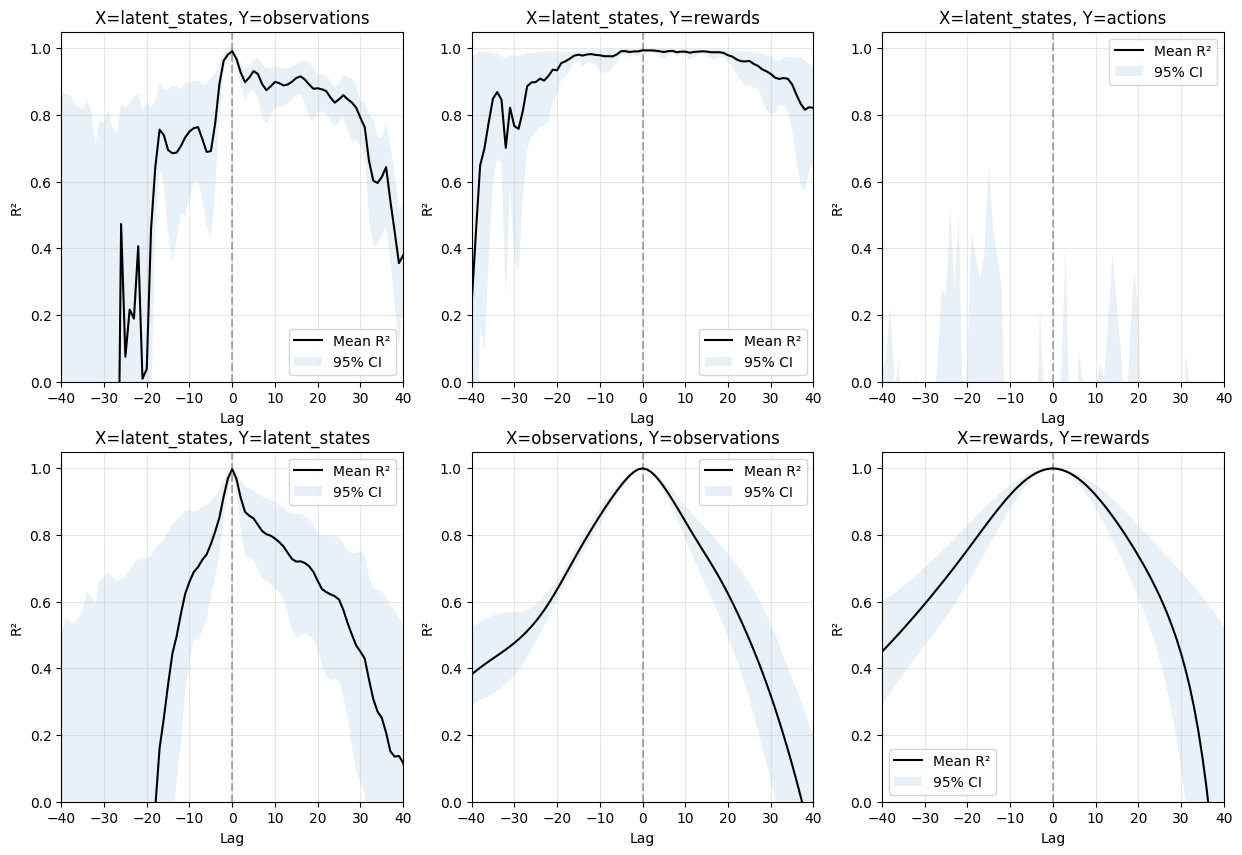

In [118]:
# Plot R2 means with bootstrapped confidence intervals for each combination
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, (key,
          results) in enumerate(results_decoding_linear_regression.items()):
    ax = axes[idx]

    r2_mean = results['r2_mean']
    r2_ci = results['r2_ci']

    # Extract lags and R² values from the dictionary
    lags = list(r2_mean.keys())
    means = list(r2_mean.values())

    # r2_ci is a tuple of (lower_dict, upper_dict)
    ci_lower = [r2_ci[lag][0] for lag in lags]
    ci_upper = [r2_ci[lag][1] for lag in lags]

    ax.plot(lags, means, label='Mean R²', color='black')
    ax.fill_between(lags, ci_lower, ci_upper, alpha=0.1, label='95% CI')
    ax.set_xlabel('Lag')
    ax.set_ylabel('R²')
    title = key.split('-')
    ax.set_title(f'X={title[0]}, Y={title[1]}')
    ax.grid(True, alpha=0.3)
    #ax.axhline(y=0, color='k', linestyle='--', alpha=0.3)
    ax.axvline(x=0, color='k', linestyle='--', alpha=0.3)
    ax.legend()
    ax.set_ylim(0, 1.05)
    ax.set_xlim(-40, 40)

plt.tight_layout()
plt.show()


## per latent LR

In [42]:
import numpy as np
from itertools import combinations
from tqdm import tqdm
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score
import seaborn as sns
import numpy as np
import itertools
import pandas as pd
import matplotlib.pyplot as plt

In [43]:
def get_model(model):
    if model == 'linear_regression':
        return LinearRegression()
    elif model == 'lasso':
        return Lasso(alpha=0.001)
    elif model == 'ridge':
        return Ridge(alpha=1.0)
    else:
        raise ValueError(f"Model {model} not supported")


def latent_semantics_leave_k_out(
    z_eps,
    y_eps,
    k_holdout=1,
    model='linear_regression',
    mode="joint",  # 'joint' or 'pairwise'
    r2_joint_mode='individual',  # 'individual' or 'global'
    max_combinations=None,
    add_bootstrap_ci=True,
    n_boot=1000,  # number of bootstrap resamples
    ci=95,  # confidence level (percent)
    random_state=0,
):
    """
    Leave-k-episodes-out CV for per-latent semantic regressions, with bootstrap CIs.

    Two modes:
        - 'joint':   y (D-dim) = W_i * z_i + b_i   (one multi-output model per latent)
        - 'pairwise': y_j = w_ij * z_i + b_ij      (one scalar model per latent–output pair)
    """
    assert mode in ("joint", "pairwise"), "mode must be 'joint' or 'pairwise'"

    n_eps = len(z_eps)
    assert n_eps > k_holdout, "k_holdout must be smaller than number of episodes"

    rng = np.random.default_rng(random_state)
    all_combos = list(combinations(range(n_eps), k_holdout))
    if max_combinations is not None and len(all_combos) > max_combinations:
        idxs = rng.choice(len(all_combos), size=max_combinations, replace=False)
        all_combos = [all_combos[i] for i in idxs]

    L = z_eps[0].shape[1]  # number of x dimensions (e.g. latent dims)
    D = y_eps[0].shape[1]  # number of y dimensions (e.g. observation dims)

    # special handling for global R² (single scalar)
    if mode == 'joint' and r2_joint_mode == 'global':
        D_out = 1
    else:
        D_out = D

    r2_by_fold = {}
    #r2_by_fold_train = {}
    fold_idx = 0

    for test_idxs in tqdm(all_combos, desc=f"Leave-{k_holdout}-out ({mode})"):
        test_idxs = np.atleast_1d(test_idxs)
        train_idxs = [i for i in range(n_eps) if i not in test_idxs]

        # Concatenate training and test data
        z_train = np.concatenate([z_eps[i] for i in train_idxs], axis=0)
        y_train = np.concatenate([y_eps[i] for i in train_idxs], axis=0)
        z_test = np.concatenate([z_eps[j] for j in test_idxs], axis=0)
        y_test = np.concatenate([y_eps[j] for j in test_idxs], axis=0)

        #fold_r2_train = np.full((L, D_out), np.nan)
        fold_r2 = np.full((L, D_out), np.nan)

        if mode == "joint":
            # one multi-output regression per latent
            for i in range(L):
                xi_tr = z_train[:, i:i + 1]
                xi_te = z_test[:, i:i + 1]
                model_to_fit = get_model(model).fit(xi_tr, y_train)
                y_pred = model_to_fit.predict(xi_te)

                if r2_joint_mode == 'individual':
                    for d in range(D):
                        fold_r2[i, d] = r2_score(y_test[:, d], y_pred[:, d])
                elif r2_joint_mode == 'global':
                    fold_r2[i, 0] = r2_score(y_test,
                                             y_pred,
                                             multioutput='variance_weighted')

        elif mode == "pairwise":
            # one scalar regression per latent-output pair
            for i in range(L):
                xi_tr = z_train[:, i]
                xi_te = z_test[:, i]
                for d in range(D):
                    model_to_fit = get_model(model).fit(xi_tr.reshape(-1, 1),
                                                        y_train[:, d])
                    y_pred = model_to_fit.predict(xi_te.reshape(-1, 1))
                    fold_r2[i, d] = r2_score(y_test[:, d], y_pred)
                    # fold_r2_train[i, d] = r2_score(
                    #     y_train[:, d],
                    #     model_to_fit.predict(xi_tr.reshape(-1, 1)))
        r2_by_fold[fold_idx] = fold_r2
        #r2_by_fold_train[fold_idx] = fold_r2_train
        fold_idx += 1

    # stack folds → (n_folds, L, D_out)
    r2_stack = np.stack(list(r2_by_fold.values()), axis=0)
    r2_mean = np.nanmean(r2_stack, axis=0)
    r2_std = np.nanstd(r2_stack, axis=0, ddof=1)

    results = {
        'r2_mean': r2_mean,
        'r2_std': r2_std,
        'r2_by_fold': r2_by_fold,
    }

    # -----------------------------
    # Bootstrap confidence intervals
    # -----------------------------

    if add_bootstrap_ci:
        print("Computing bootstrap CIs")
        alpha_p = (100 - ci) / 2
        lower = np.full((L, D_out), np.nan)
        upper = np.full((L, D_out), np.nan)

        for i in tqdm(range(L), desc="Bootstrapping CIs"):
            for d in range(D_out):
                vals = r2_stack[:, i, d]
                vals = vals[~np.isnan(vals)]
                if len(vals) == 0:
                    continue
                boot_means = np.zeros(n_boot)
                for b in range(n_boot):
                    sample = rng.choice(vals, size=len(vals), replace=True)
                    boot_means[b] = np.mean(sample)
                lower[i, d] = np.percentile(boot_means, alpha_p)
                upper[i, d] = np.percentile(boot_means, 100 - alpha_p)

        r2_ci = np.stack([lower, upper], axis=-1)  # (L, D_out, 2)
        results['r2_ci'] = r2_ci

    return results

In [102]:
# z_eps, y_eps = list of arrays per episode

x_var = 'latent_states'
y_var = 'observations'

results_obs = latent_semantics_leave_k_out(exp_vars[x_var],
                                           exp_vars[y_var],
                                           k_holdout=1,
                                           model='linear_regression',
                                           mode='pairwise')

Leave-1-out (pairwise):   0%|          | 0/9 [00:00<?, ?it/s]

Leave-1-out (pairwise): 100%|██████████| 9/9 [00:21<00:00,  2.40s/it]


Computing bootstrap CIs


Bootstrapping CIs: 100%|██████████| 512/512 [00:38<00:00, 13.47it/s]


In [53]:
x_var = 'latent_states'
y_var = 'rewards'
results_rew = latent_semantics_leave_k_out(exp_vars[x_var],
                                           exp_vars[y_var],
                                           k_holdout=1,
                                           model='linear_regression',
                                           mode='pairwise')

x_var = 'latent_states'
y_var = 'actions'
results_act = latent_semantics_leave_k_out(exp_vars[x_var],
                                           exp_vars[y_var],
                                           k_holdout=1,
                                           model='linear_regression',
                                           mode='pairwise')

Leave-1-out (pairwise): 100%|██████████| 9/9 [00:04<00:00,  2.12it/s]


Computing bootstrap CIs


Leave-1-out (pairwise): 100%|██████████| 9/9 [00:04<00:00,  2.13it/s]


Computing bootstrap CIs


Bootstrapping CIs: 100%|██████████| 512/512 [00:07<00:00, 65.83it/s]


In [103]:
r2_mean = np.concatenate(
    [results_obs['r2_mean'], results_rew['r2_mean'], results_act['r2_mean']],
    axis=1)
r2_std = np.concatenate(
    [results_obs['r2_std'], results_rew['r2_std'], results_act['r2_std']],
    axis=1)
r2_ci = np.concatenate(
    [results_obs['r2_ci'], results_rew['r2_ci'], results_act['r2_ci']], axis=1)
# r2_by_fold = np.concatenate([
#     results['r2_by_fold'], results_rew['r2_by_fold'], results_act['r2_by_fold']
# ],
#                             axis=0)

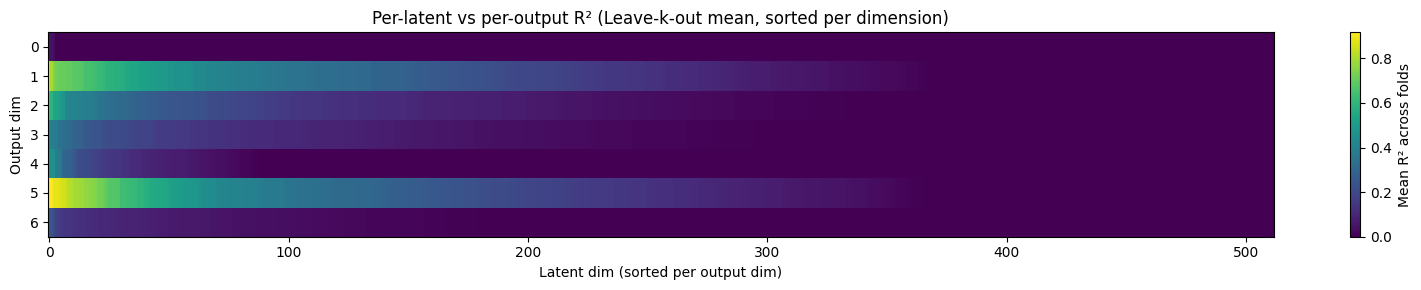

In [104]:
# Sort latent dimensions by their overall magnitude per output dimension

r2_mean = np.maximum(r2_mean, 0)

# Sort each output dimension independently by the magnitude of latent contributions
sorted_r2_mean = np.zeros_like(r2_mean)
for d in range(r2_mean.shape[1]):
    sorted_indices_d = np.argsort(r2_mean[:, d])[::-1]
    sorted_r2_mean[:, d] = r2_mean[sorted_indices_d, d]

plt.figure(figsize=(16, 3))
plt.imshow(sorted_r2_mean.T,
           cmap='viridis',
           interpolation='none',
           aspect='auto',
           vmin=0,
           vmax=r2_mean.max())

plt.colorbar(label='Mean R² across folds')
plt.xlabel('Latent dim (sorted per output dim)')
plt.ylabel('Output dim')
plt.title(
    'Per-latent vs per-output R² (Leave-k-out mean, sorted per dimension)')
plt.tight_layout()
plt.show()

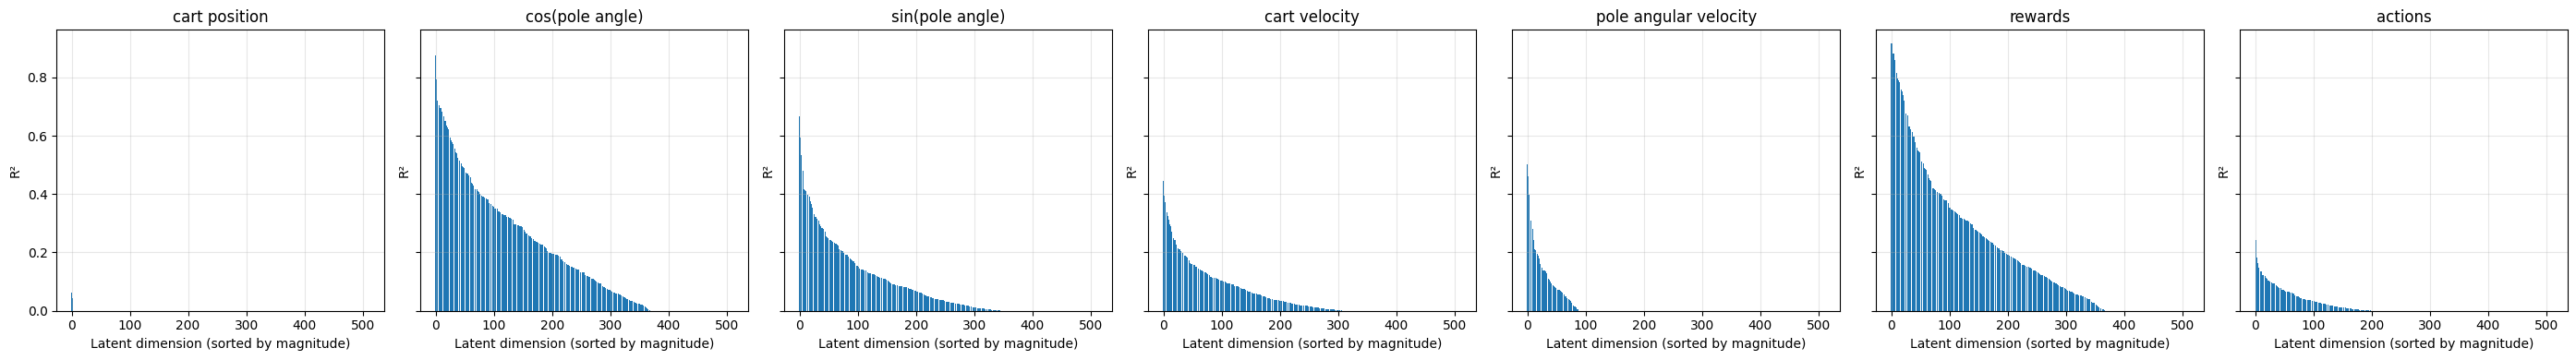

In [105]:
# Create a barplot for each output dimension showing R² vs latent dimension
n_output_dims = r2_mean.shape[1]
n_latent_dims = r2_mean.shape[0]

# Option to sort bars by magnitude
sort_by_magnitude = True

fig, axes = plt.subplots(1,
                         n_output_dims,
                         figsize=(4 * n_output_dims, 4),
                         sharey=True)
if n_output_dims == 1:
    axes = [axes]

for d in range(n_output_dims):
    if sort_by_magnitude:
        # Sort by magnitude (descending)
        sorted_indices = np.argsort(r2_mean[:, d])[::-1]
        sorted_values = r2_mean[sorted_indices, d]
        axes[d].bar(np.arange(n_latent_dims), sorted_values)
        axes[d].set_xlabel('Latent dimension (sorted by magnitude)')
    else:
        axes[d].bar(np.arange(n_latent_dims), r2_mean[:, d])
        axes[d].set_xlabel('Latent dimension')

    axes[d].set_ylabel('R²')
    axes[d].set_title(varsname_dict_ext[d])
    axes[d].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


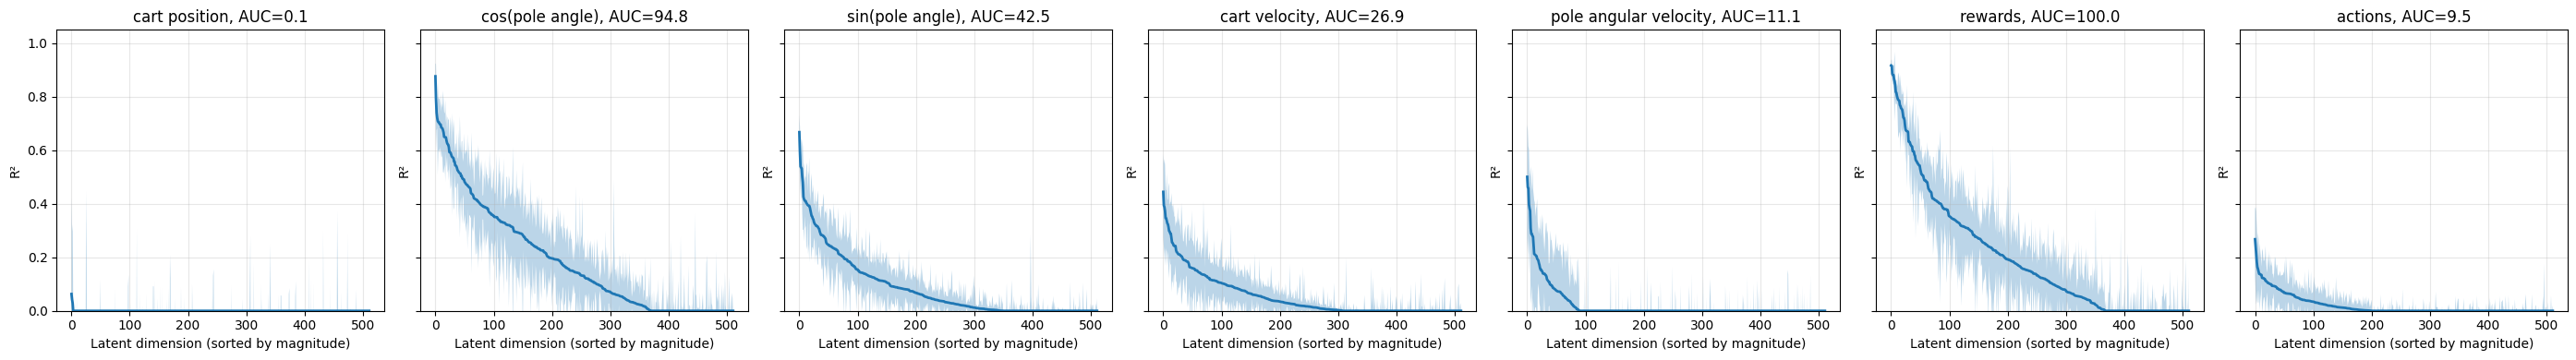

In [108]:
# Create a line plot for each output dimension showing R² vs latent dimension with confidence intervals
n_output_dims = r2_mean.shape[1]
n_latent_dims = r2_mean.shape[0]

# Option to sort by magnitude
sort_by_magnitude = True

fig, axes = plt.subplots(1,
                         n_output_dims,
                         figsize=(4 * n_output_dims, 4),
                         sharey=True)
if n_output_dims == 1:
    axes = [axes]

for d in range(n_output_dims):
    auc = np.trapz(r2_mean[:, d], x)

    if sort_by_magnitude:
        # Sort by magnitude (descending)
        sorted_indices = np.argsort(r2_mean[:, d])[::-1]
        sorted_values = r2_mean[sorted_indices, d]
        sorted_lower = r2_ci[sorted_indices, d, 0]
        sorted_upper = r2_ci[sorted_indices, d, 1]

        x = np.arange(n_latent_dims)
        axes[d].plot(x, sorted_values, linewidth=2)
        axes[d].fill_between(x, sorted_lower, sorted_upper, alpha=0.3)
        axes[d].set_xlabel('Latent dimension (sorted by magnitude)')
    else:
        x = np.arange(n_latent_dims)
        axes[d].plot(x, r2_mean[:, d], linewidth=2)
        axes[d].fill_between(x, r2_ci[:, d, 0], r2_ci[:, d, 1], alpha=0.3)
        axes[d].set_xlabel('Latent dimension')

    axes[d].set_ylabel('R²')
    axes[d].set_title(f"{varsname_dict_ext[d]}, AUC={auc:.1f}")
    axes[d].grid(True, alpha=0.3)
    axes[d].set_ylim(0, 1.05)

plt.tight_layout()
plt.show()

In [63]:
def compute_overlap_matrix(active_latents_dict, metric='jaccard'):
    keys = list(active_latents_dict.keys())
    n = len(keys)
    mat = np.zeros((n, n))
    for i, j in itertools.combinations(range(n), 2):
        A, B = set(active_latents_dict[keys[i]]), set(
            active_latents_dict[keys[j]])
        inter = len(A & B)
        if metric == 'jaccard':
            val = inter / len(A | B) if (A | B) else np.nan
        elif metric == 'overlap':
            val = inter / min(len(A), len(B)) if min(len(A),
                                                     len(B)) > 0 else np.nan
        else:
            raise ValueError("metric must be 'jaccard' or 'overlap'")
        mat[i, j] = mat[j, i] = val
    np.fill_diagonal(mat, 1.0)
    return pd.DataFrame(mat, index=keys, columns=keys)


def get_active_latents(r2_mean,
                       mode='threshold',
                       threshold=0.0,
                       k=10,
                       percentile=90):
    active_latents = {}
    if mode == 'threshold':
        for d in range(n_output_dims):
            active_latents[d] = np.nonzero(r2_mean[:, d] > threshold)[0]
    elif mode == 'topk':
        for d in range(n_output_dims):
            # Get indices of top k latents by R² value
            top_k_indices = np.argsort(r2_mean[:, d])[-k:]
            # Filter to only those with positive R²
            active_latents[d] = top_k_indices[r2_mean[top_k_indices, d] > 0]
    elif mode == 'percentile':
        for d in range(n_output_dims):
            # Compute percentile threshold for this dimension
            pct_threshold = np.percentile(r2_mean[:, d], percentile)
            active_latents[d] = np.nonzero(r2_mean[:, d] > pct_threshold)[0]
    else:
        raise ValueError("mode must be 'threshold', 'topk', or 'percentile'")
    return active_latents


# active_latents = get_active_latents(r2_mean, mode='percentile', percentile=70)
# overlap_df = compute_overlap_matrix(active_latents, metric='overlap')

# sns.heatmap(overlap_df, annot=True, cmap='magma')
# plt.show()

In [64]:
import numpy as np

Ks = np.arange(1, 201)


def mean_overlap_from_matrix(overlap_df):
    mat = overlap_df.values if hasattr(overlap_df,
                                       "values") else np.array(overlap_df)
    n = mat.shape[0]
    tri_upper = mat[np.triu_indices(n, k=1)]  # off-diagonal upper triangle
    return np.nanmean(tri_upper)


overlap_mats = {}
for k in Ks:
    active_latents = get_active_latents(r2_mean, mode='topk', k=k)

    overlap_df = compute_overlap_matrix(active_latents, metric='overlap')
    overlap_mats[k] = overlap_df

mean_overlaps = []
for mat in overlap_mats.values():
    mean_overlaps.append(mean_overlap_from_matrix(mat))

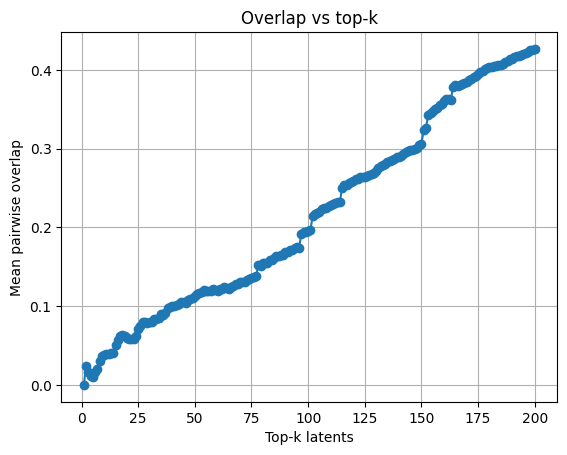

In [65]:
plt.plot(Ks, mean_overlaps, marker='o')
plt.xlabel('Top-k latents')
plt.ylabel('Mean pairwise overlap')
plt.title('Overlap vs top-k')
plt.grid(True)

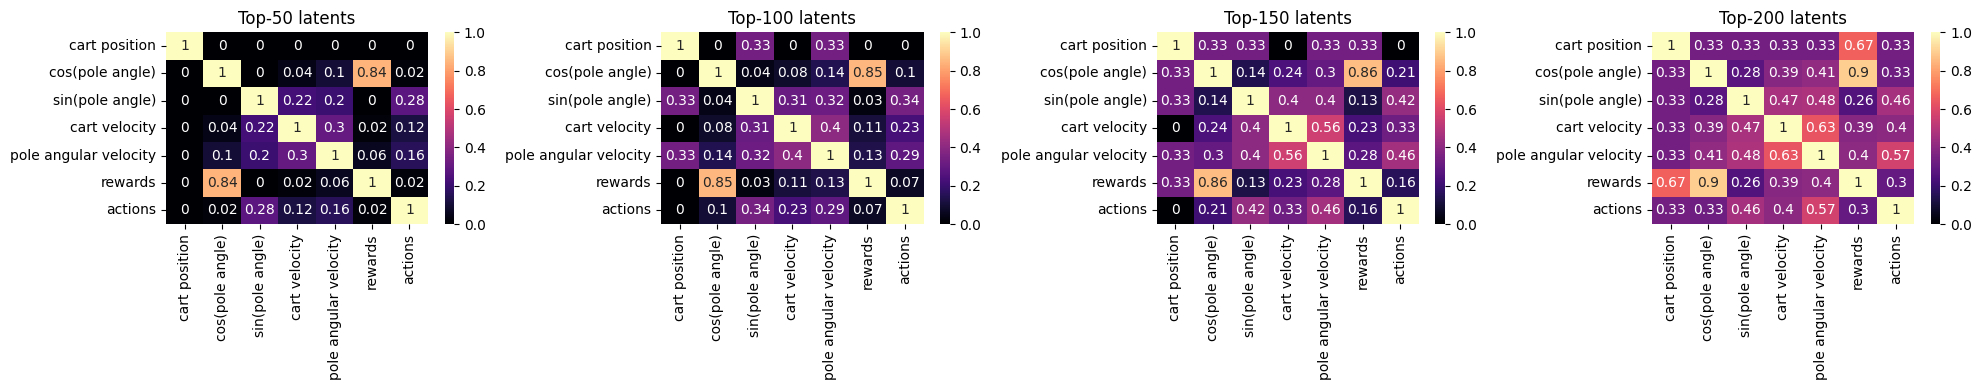

In [67]:
# Plot heatmaps for every 50th k value
selected_ks = [k for k in Ks if k % 50 == 0]
n_plots = len(selected_ks)

fig, axes = plt.subplots(1, n_plots, figsize=(5 * n_plots, 4))
if n_plots == 1:
    axes = [axes]

for idx, k in enumerate(selected_ks):
    sns.heatmap(overlap_mats[k],
                annot=True,
                cmap='magma',
                ax=axes[idx],
                vmin=0,
                vmax=1,
                cbar=True,
                xticklabels=varsname_dict_ext.values(),
                yticklabels=varsname_dict_ext.values())
    axes[idx].set_title(f'Top-{k} latents')

plt.tight_layout()
plt.show()


## LASSO COEFFICIENTS

In [68]:
lasso_models = results_decoding['latent_states-observations']['model_by_lag'][0]

NameError: name 'results_decoding' is not defined

In [129]:
W_list = [m.coef_.T for m in lasso_models]  # list of (L, D) arrays
W_stack = np.stack(W_list, axis=0)  # shape (K, L, D)
K, L, D = W_stack.shape

In [130]:
mean_W = W_stack.mean(axis=0)  # (L, D)
std_W = W_stack.std(axis=0)  # (L, D)

# optional: selection frequency (how often nonzero)
freq_W = (np.abs(W_stack) > 1e-6).mean(axis=0)  # fraction of folds where la

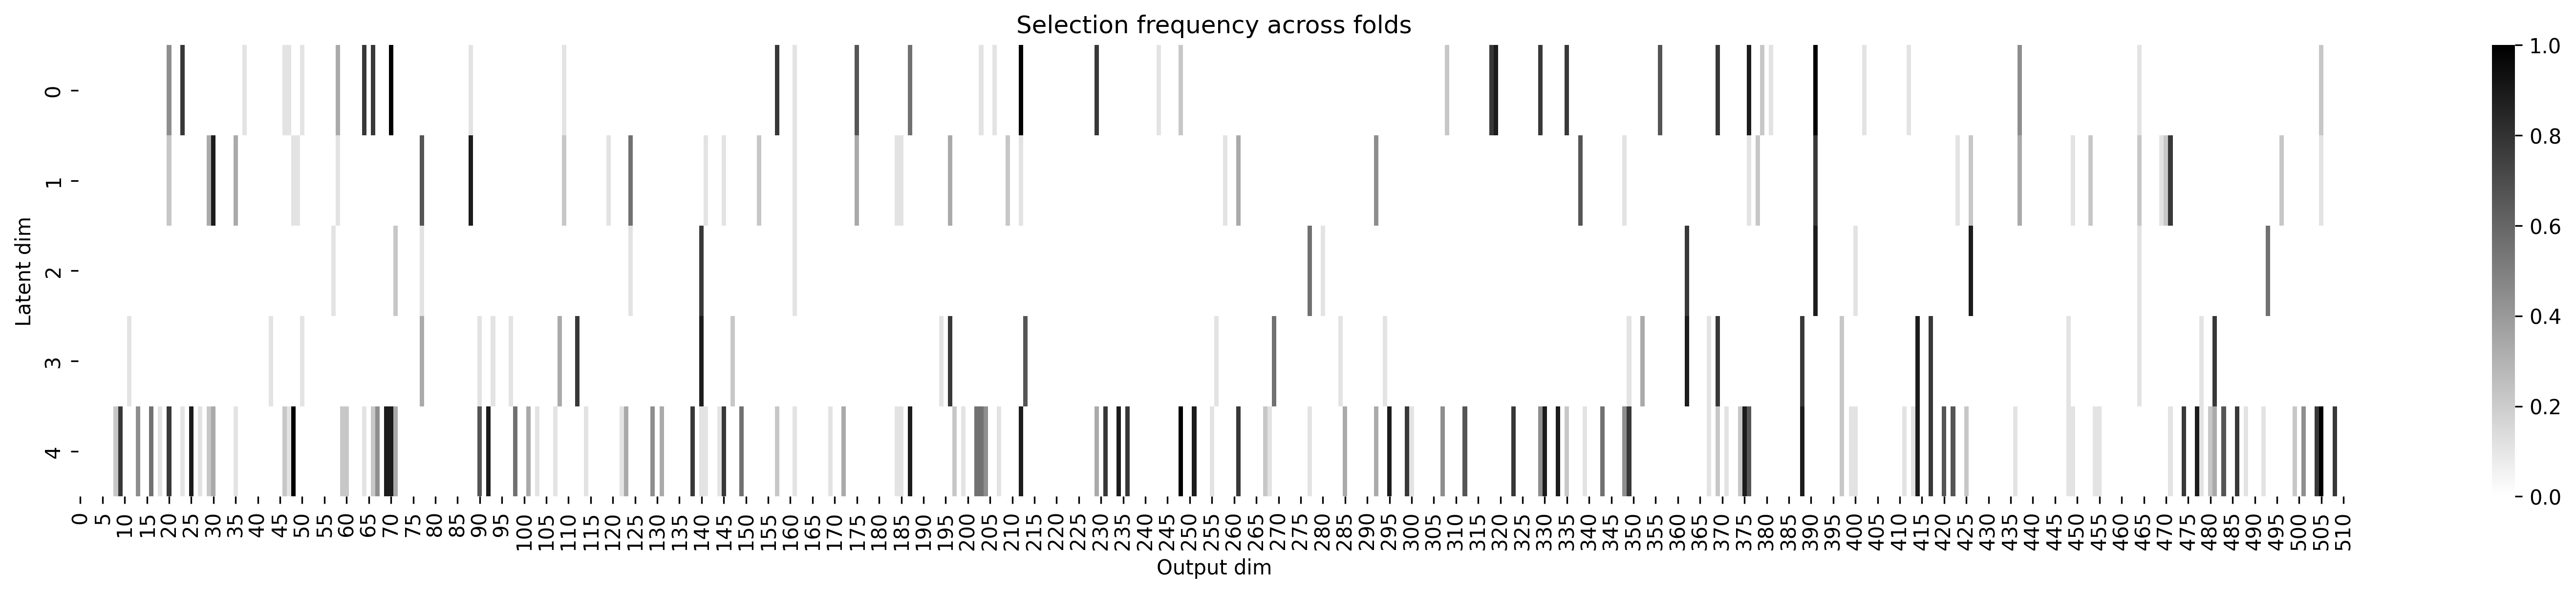

In [131]:
plt.figure(figsize=(25, 4), dpi=300)
sns.heatmap(freq_W.T, cmap='gray_r', annot=False)
plt.xlabel('Output dim')
plt.ylabel('Latent dim')
plt.title('Selection frequency across folds')
plt.show()


In [ ]:
W_list[0].T.min()§§§

-3.836254

<Axes: >

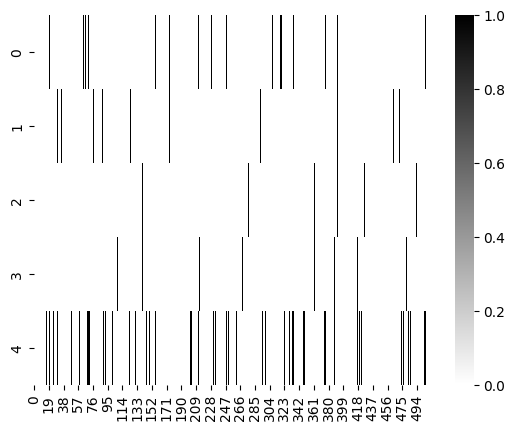

In [136]:
sns.heatmap((np.abs(W_list[0].T) > 1e-6).astype(float),
            cmap='gray_r',
            annot=False)

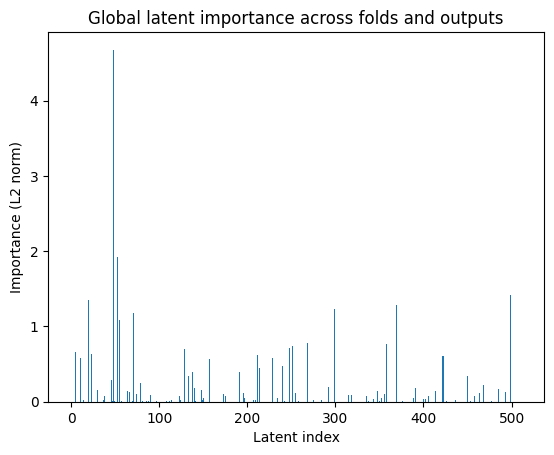

In [120]:
global_importance = np.sqrt((mean_W**2).sum(axis=1))
plt.bar(np.arange(L), global_importance)
plt.title("Global latent importance across folds and outputs")
plt.xlabel("Latent index")
plt.ylabel("Importance (L2 norm)")
plt.show()

Mean within-fold overlap = 0.081


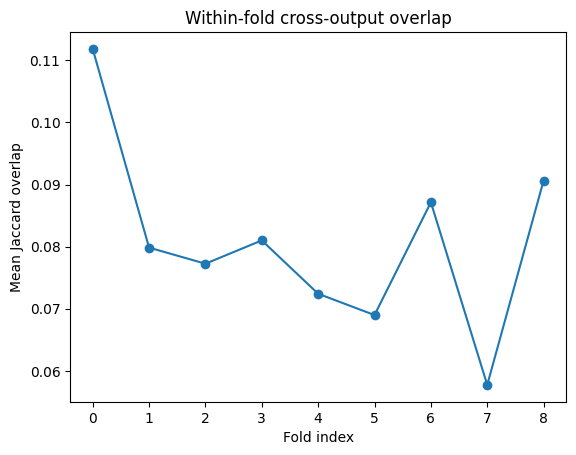

In [121]:
from itertools import combinations


def overlap_within_fold(W, threshold=1e-6):
    L, D = W.shape
    overlaps = []
    for i, j in combinations(range(D), 2):
        A = set(np.where(np.abs(W[:, i]) > threshold)[0])
        B = set(np.where(np.abs(W[:, j]) > threshold)[0])
        if len(A | B) > 0:
            overlaps.append(len(A & B) / len(A | B))
    return np.mean(overlaps) if overlaps else np.nan


overlap_per_fold = [overlap_within_fold(W_stack[k]) for k in range(K)]
print(f"Mean within-fold overlap = {np.mean(overlap_per_fold):.3f}")
plt.plot(overlap_per_fold, marker='o')
plt.title("Within-fold cross-output overlap")
plt.xlabel("Fold index")
plt.ylabel("Mean Jaccard overlap")
plt.show()


Mean sparsity fraction = 0.037


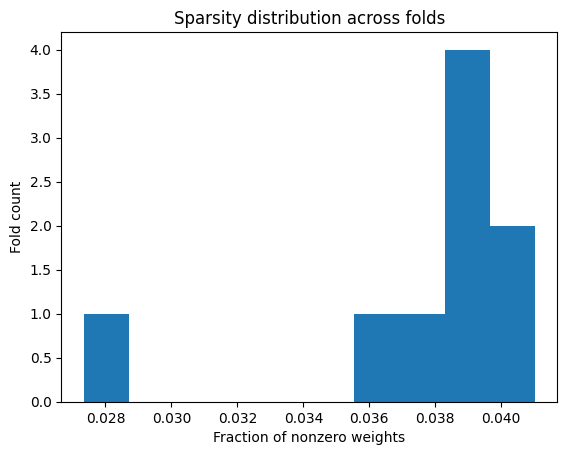

In [122]:
nonzeros_per_fold = (np.abs(W_stack) > 1e-6).sum(axis=(1, 2)) / (L * D)
print(f"Mean sparsity fraction = {np.mean(nonzeros_per_fold):.3f}")
plt.hist(nonzeros_per_fold)
plt.xlabel("Fraction of nonzero weights")
plt.ylabel("Fold count")
plt.title("Sparsity distribution across folds")
plt.show()

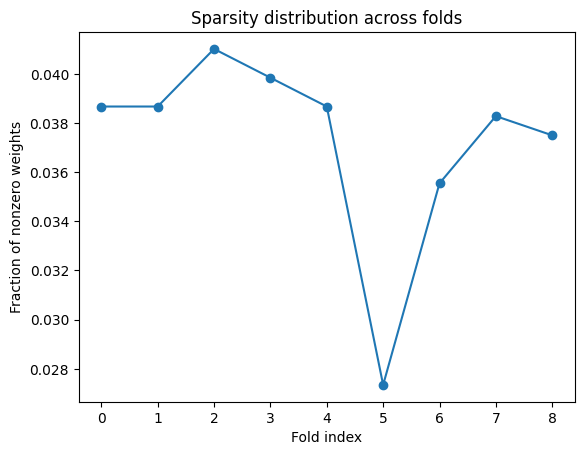

In [138]:
plt.plot(nonzeros_per_fold, marker='o')
plt.title("Sparsity distribution across folds")
plt.xlabel("Fold index")
plt.ylabel("Fraction of nonzero weights")
plt.show()
